In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv('../results/skip_sim.csv', names=['video', 'frame', 'name', 'similarity'])
df

,video,frame,name,similarity
0,client/pred_videos/videoa1-1_eval.mp4,0,RobiyaAbdullayeva,0.274247
1,client/pred_videos/videoa1-1_eval.mp4,0,Oydina Yo'ldasheva,0.393428
2,client/pred_videos/videoa1-1_eval.mp4,0,Mohira Murodova,0.322447
3,client/pred_videos/videoa1-1_eval.mp4,0,Akmal Nazarov,0.102681
4,client/pred_videos/videoa1-1_eval.mp4,0,Sadoqat Murodaliyeva,0.107987
...,...,...,...,...
358969,client/pred_videos/videoa1-5_eval.mp4,15,Ug'iloyHusniddinova,-0.208119
358970,client/pred_videos/videoa1-5_eval.mp4,15,SevaraYoqubbekova,0.174378
358971,client/pred_videos/videoa1-5_eval.mp4,15,AzizovaMuyassar,-0.024584
358972,client/pred_videos/videoa1-5_eval.mp4,15,Bilolxon Akramov Rosuljon o'g'li,0.148572


In [42]:
df['video'] = df['video'] = df['video'].apply(lambda x: x.split('/')[-1].split('.')[0].split('_')[0])
df

,video,frame,name,similarity
0,videoa1-1,0,RobiyaAbdullayeva,0.274247
1,videoa1-1,0,Oydina Yo'ldasheva,0.393428
2,videoa1-1,0,Mohira Murodova,0.322447
3,videoa1-1,0,Akmal Nazarov,0.102681
4,videoa1-1,0,Sadoqat Murodaliyeva,0.107987
...,...,...,...,...
358969,videoa1-5,15,Ug'iloyHusniddinova,-0.208119
358970,videoa1-5,15,SevaraYoqubbekova,0.174378
358971,videoa1-5,15,AzizovaMuyassar,-0.024584
358972,videoa1-5,15,Bilolxon Akramov Rosuljon o'g'li,0.148572


In [43]:
import os
import json

df_video_names = df['video'].unique()
video_to_name = {}
gt_names_path = '/home/hbvision/mirsaid/smart-office/annotations'
for annot in os.listdir(gt_names_path):
    video_name = annot.split('_')[-1].split('.')[0]

    if video_name in df_video_names:
        # Open Json file
        with open(os.path.join(gt_names_path, annot)) as f:
            data = json.load(f)
        video_to_name[video_name] = list(data.values())

video_to_name

{'videoa1-5': ['Feruza Yusupova',
  'Yoqubjon Yusufxanov',
  "Dilafruz Yo'ldoshbayeva",
  'Murod Samsaqbayev',
  'Mashrab Muydinov'],
 'videoa1-3': ['Unknown',
  'Unknown',
  'ShaxnozaMadmusayeva',
  'ElsevarToshmirzayeva',
  'Viloyat Elnazarova',
  'Dilrabo Egamova',
  "NafisaTurg'unova",
  "NasibaJo'rabayeva",
  'Nodira Umarova'],
 'videoa1-2': ['Unknown',
  'Toshbayeva Yulduz',
  'Zamira Nurmatova',
  'Burxaniddinova Muazzam',
  'Unknown'],
 'videoa1-4': ['Unknown',
  'GulchexraObidova',
  'OydinaRahmonova',
  'Erkinoy Atajanova',
  'MohidilOdiljonova',
  'Dilfuza Mamadaliyeva',
  'Nargiza Raximova',
  'Maftuna Mamajanova',
  'Sevinch Marupova',
  "Turg'unoy Razzoqova"],
 'videoa1-1': ['DilraboQobilova',
  'NargizaMirzayeva',
  'Unknown',
  'EtiborSarimsoqova',
  'DilshodaJalilova',
  "Manzura Qo'qonova",
  'Zuhra Dolimova',
  'Pattayeva Muqaddas',
  "Sevara Qo'qonova",
  'Barno Shamsiddinova']}

In [44]:
# For each video, calculate average similarity for each name if it is present in the ground truth
video_to_avg_similarity = {}

for video, names in video_to_name.items():
    video_df = df[df['video'] == video]
    video_to_avg_similarity[video] = {}
    for name in names:
        name_df = video_df[video_df['name'] == name]
        if len(name_df) > 0:
            avg_similarity = name_df['similarity'].max()
            video_to_avg_similarity[video][name] = f'Person appeared {len(name_df)} times with average {avg_similarity*100} similarity'
        else:
            video_to_avg_similarity[video][name] = 0
        
video_to_avg_similarity

{'videoa1-5': {'Feruza Yusupova': 'Person appeared 208 times with average 62.307870388031006 similarity',
  'Yoqubjon Yusufxanov': 'Person appeared 208 times with average 51.652514934539795 similarity',
  "Dilafruz Yo'ldoshbayeva": 'Person appeared 208 times with average 85.74413061141968 similarity',
  'Murod Samsaqbayev': 'Person appeared 208 times with average 58.15010666847229 similarity',
  'Mashrab Muydinov': 'Person appeared 208 times with average 81.6765546798706 similarity'},
 'videoa1-3': {'Unknown': 0,
  'ShaxnozaMadmusayeva': 'Person appeared 698 times with average 86.59464716911316 similarity',
  'ElsevarToshmirzayeva': 'Person appeared 698 times with average 57.0808470249176 similarity',
  'Viloyat Elnazarova': 'Person appeared 698 times with average 64.76088166236877 similarity',
  'Dilrabo Egamova': 'Person appeared 698 times with average 72.00843095779419 similarity',
  "NafisaTurg'unova": 'Person appeared 698 times with average 72.27267622947693 similarity',
  "Nasiba

In [46]:
video_to_avg_similarity['videoa1-1']

{'DilraboQobilova': 'Person appeared 1440 times with average 81.01476430892944 similarity',
 'NargizaMirzayeva': 'Person appeared 1440 times with average 75.86816549301147 similarity',
 'Unknown': 0,
 'EtiborSarimsoqova': 'Person appeared 1440 times with average 68.96269917488098 similarity',
 'DilshodaJalilova': 'Person appeared 1440 times with average 80.43716549873352 similarity',
 "Manzura Qo'qonova": 'Person appeared 1440 times with average 77.77570486068726 similarity',
 'Zuhra Dolimova': 'Person appeared 1440 times with average 77.38223671913147 similarity',
 'Pattayeva Muqaddas': 'Person appeared 1440 times with average 76.42948031425476 similarity',
 "Sevara Qo'qonova": 'Person appeared 1440 times with average 71.74755334854126 similarity',
 'Barno Shamsiddinova': 'Person appeared 1440 times with average 71.09956741333008 similarity'}

In [2]:
import pickle

emb_path = '/home/hbvision/Desktop/face-recognition/data/embeddings/hb-kor-camera.pkl'

with open(emb_path, 'rb') as f:
    data = pickle.load(f)

names = data['names']
embeddings = data['embeddings']

In [4]:
embeddings.shape

(143, 512)

In [5]:
print(names)   

['Bahodir N_4', 'Bathuu_6', 'Bahodir N_6', 'Bahodir N_3', 'Eliyor_4', 'Bahodirjon_6', 'Azizbek_8', 'Maruf_10', 'Otabek_9', 'Jumabek_5', 'Jumabek_6', 'Omadbek', 'Bahodir_9', 'Eliyor_7', 'Uktam_2', 'Azamat_2', 'Kamron_6', 'Bahodirjon_5', 'Gofurjon_1', 'Oybek_7', 'Azizbek_1', 'Jumabek_9', 'Abdulloh_1', 'Javohir_1', 'Dilshod_8', 'Oybek_9', 'Asadbek_1', 'Bathuu_1', 'Arsen_2', 'Shoxruh_2', 'Kamron_2', 'Shoxruh_6', 'Gofurjon_10', 'Kamron', 'Diyorjon_5', 'Oybek_3', 'Javohir_7', 'Omadbek_1', 'Abdulloh_9', 'Javohir_9', 'Bathuu_10', 'Kamron_3', 'Mironshox_8', 'Diyorjon_6', 'Sokhib_4', 'Shoxruh_8', 'Murtazo_3', 'Bahodir_1', 'Dilshod_3', 'Bathuu_5', 'Shoxruh_3', 'Sokhib_1', 'Jumabek_3', 'Sokhib_8', 'Murtazo_6', 'Mironshox_7', 'Bahodir N_1', 'Oybek_1', 'Humoyun_8', 'Eliyor_1', 'Mironshox_10', 'Jumabek_10', 'Dilshod_2', 'Arsen_1', 'Shoxruh_7', 'Bahodirjon_4', 'Dilshod_7', 'Mirsaid', 'Mironshox_3', 'Sokhib_9', 'Murtazo_8', 'Kamron_7', 'Bathuu_7', 'Humoyun_1', 'Maruf_7', 'Maruf_1', 'Jumabek_4', 'Dilsho

/home/hbvision/Desktop/face-recognition/myenv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


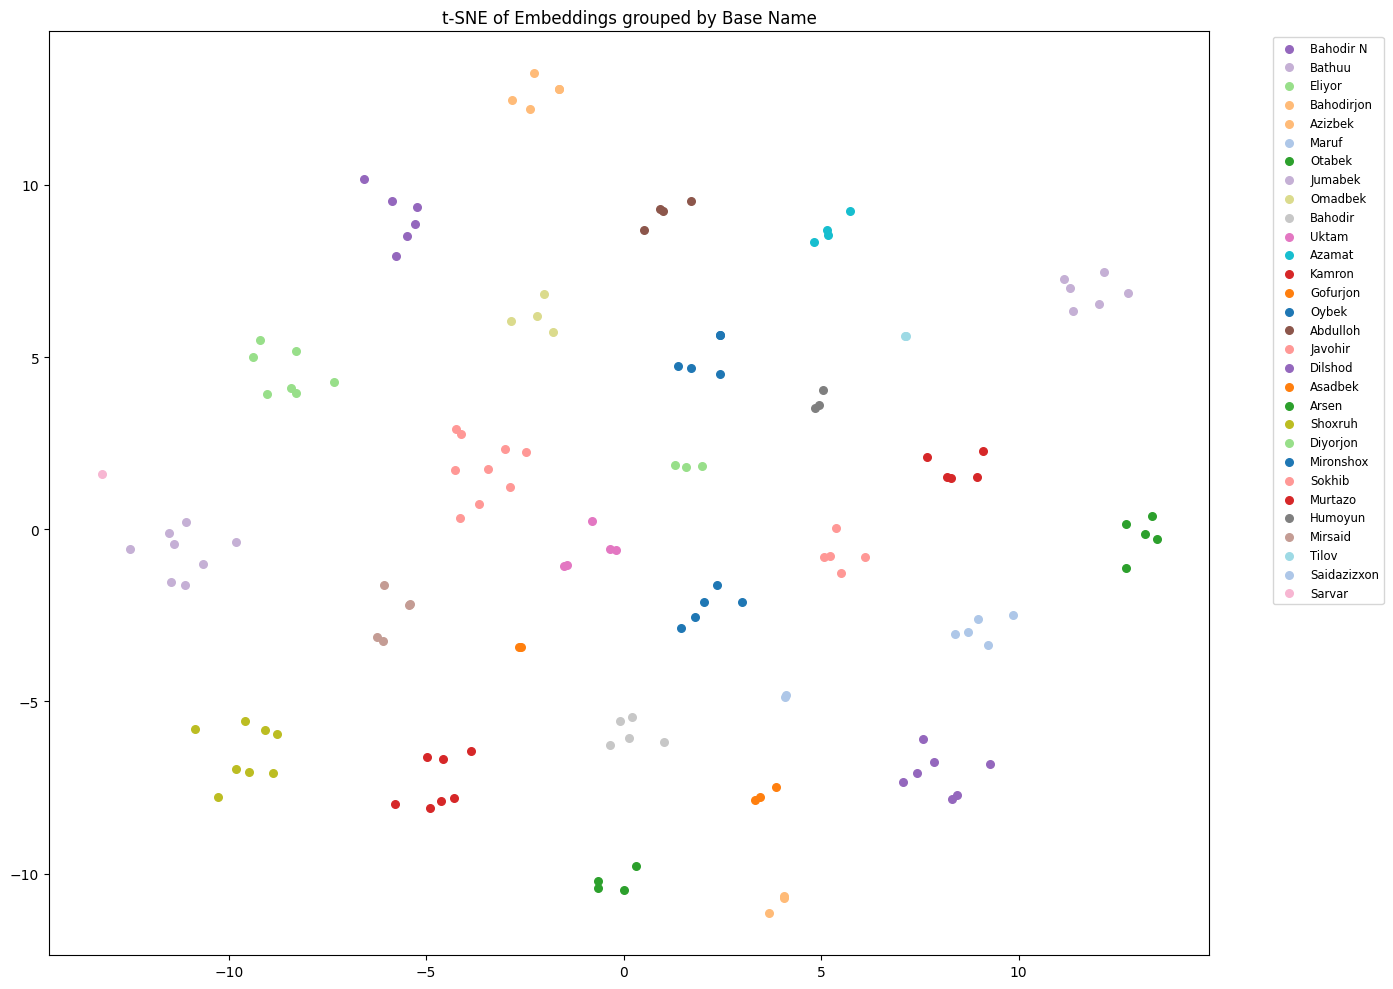

In [6]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Step 1: Extract base names (before underscore or as-is)
base_names = [name.split('_')[0] for name in names]

# Step 2: Convert embeddings to numpy array
embeddings_np = np.array(embeddings)

# Step 3: Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings_np)

# Step 4: Plot with color coding per base name
plt.figure(figsize=(14, 10))
unique_labels = list(set(base_names))
label_to_color = {label: plt.cm.tab20(i % 20) for i, label in enumerate(unique_labels)}

for i, label in enumerate(base_names):
    x, y = embeddings_2d[i]
    plt.scatter(x, y, color=label_to_color[label], label=label if label not in plt.gca().get_legend_handles_labels()[1] else "", s=30)

plt.title("t-SNE of Embeddings grouped by Base Name")
plt.legend(loc='best', fontsize='small', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()
